EOS sweep: n=30 kT=0.700 rho=0.815 direction=up
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.815/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
EOS sweep: n=30 kT=0.700 rho=0.820 direction=up
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.820/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
EOS sweep: n=30 kT=0.700 rho=0.825 direction=up
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.825/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
EOS sweep: n=30 kT=0.700 rho=0.810 direction=down
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.810/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
EOS sweep: n=30 kT=0.700 rho=0.805 direction=down
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_State

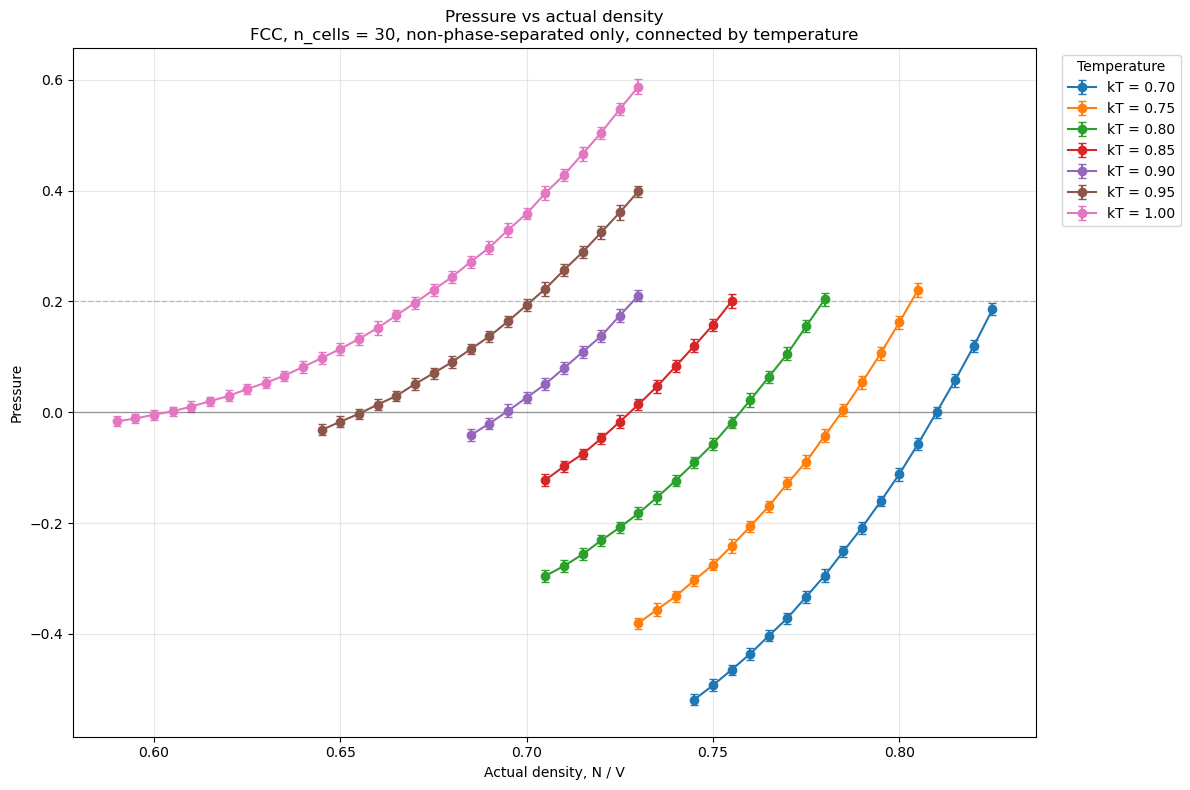

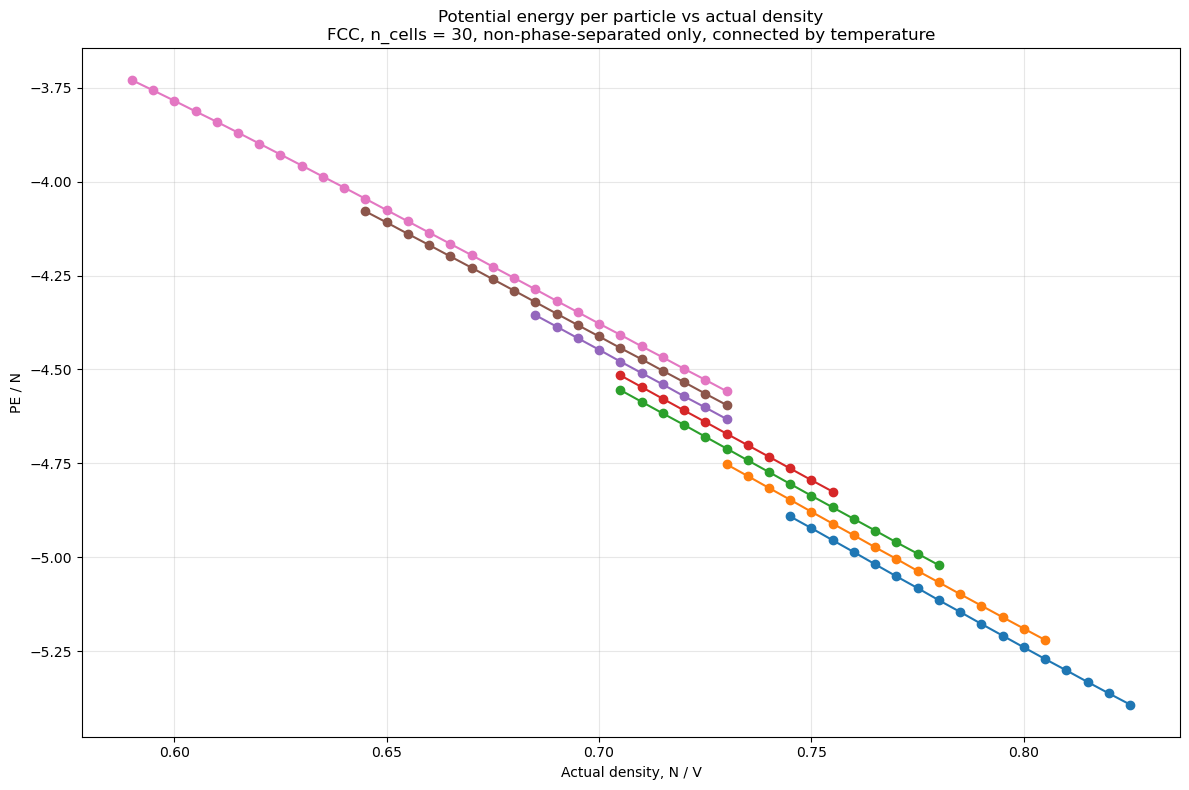

,kT,target_rho,actual_rho,pressure_mean_last100
0,0.7,0.745,0.745,-0.518705
1,0.7,0.750,0.750,-0.492886
2,0.7,0.755,0.755,-0.464918
3,0.7,0.760,0.760,-0.435991
4,0.7,0.765,0.765,-0.403410
...,...,...,...,...
112,1.0,0.710,0.710,0.428214
113,1.0,0.715,0.715,0.466448
114,1.0,0.720,0.720,0.504747
115,1.0,0.725,0.725,0.547396


n_fcc_cells: 10 kT: 0.7 densities: [np.float64(0.81), np.float64(0.815), np.float64(0.82)]
Thermalized state exists: checking phase separation.
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.810/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
Thermalized state exists: checking phase separation.
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.810/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
Thermalized state good; continuing to cavitation.


Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_10/source_rho_0.810/kT_0.700/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_2.000/center_box/cavitation_initial.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fbaeee9e270>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/

KeyboardInterrupt: 

In [ ]:
import numpy as np

from md_Helpers import cavitation
from md_Helpers import eos_sweep

kT_values = [0.700, 0.750, 0.800, 0.850]
n_fcc_cells_values = [10, 12, 15, 17, 20, 22, 25, 27, 30]
radii = [2.0, 3.0, 4.0, 5.0]

source_nsteps = 1_000_000
evolve_nsteps = 100_000
source_seed = 1
evolve_seed = 1

# Build/load EOS pressure-window sweep for n_cells=30.
eos_summary = eos_sweep.run_eos_pressure_window_sweep(
    n_fcc_cells=30,
    kT_start=min(kT_values),
    kT_stop=max(kT_values),
    kT_step=0.050,
    initial_rho=0.710,
    rho_step=0.005,
    nsteps=source_nsteps,
    seed=source_seed,
    overwrite=False,
)

pressure_window = (-0.03, 0.18)
pressure_n_last = 100
pressure_col = f"pressure_mean_last{pressure_n_last}"

# Display and plot the EOS table used to choose cavitation densities.
eos_view = eos_sweep.plot_eos_density_curves(
    eos_summary,
    n_last=pressure_n_last,
    n_fcc_cells=30,
    save=False,
    show=True,
)
display(
    eos_view["table"][
        ["kT", "target_rho", "actual_rho", pressure_col]
    ]
)

for n_fcc_cells in n_fcc_cells_values:
    for kT in kT_values:
        densities = sorted(
            eos_summary.loc[
                (np.isclose(eos_summary["kT"], kT))
                & eos_summary[pressure_col].between(*pressure_window)
                & (~eos_summary["phase_separated"].astype(bool)),
                "target_rho",
            ].round(3).unique()
        )

        print("=" * 80)
        print("n_fcc_cells:", n_fcc_cells, "kT:", kT, "densities:", densities)

        for target_rho in densities:
            source = cavitation.get_source_randomization_result(
                n_fcc_cells=n_fcc_cells,
                target_rho=target_rho,
                kT=kT,
                source_nsteps=source_nsteps,
                source_seed=source_seed,
                create_source_if_missing=True,
            )

            if source["frame"] is None:
                print("missing source:", n_fcc_cells, target_rho, kT)
                continue

            phase = cavitation._source_phase_separation(source)

            if phase["phase_separated"]:
                print("skipping phase-separated source:", n_fcc_cells, target_rho, kT)
                continue

            for radius in radii:
                result = cavitation.get_or_create_cavitation(
                    n_fcc_cells=n_fcc_cells,
                    target_rho=target_rho,
                    kT=kT,
                    source_nsteps=source_nsteps,
                    source_seed=source_seed,

                    radius=radius,

                    evolve_nsteps=evolve_nsteps,
                    evolve_seed=evolve_seed,

                    log_period=1_000,
                    trajectory_period=1_000,

                    random_location=False,

                    overwrite=False,
                    overwrite_initial=False,
                    overwrite_source=False,
                    create_source_if_missing=False,
                    reject_phase_separated_source=True,
                )

                print(
                    "cavitation:",
                    "n=", n_fcc_cells,
                    "rho=", target_rho,
                    "kT=", kT,
                    "radius=", radius,
                    "status=", result["status"],
                )